In [1]:
# Importiamo le librerie necessarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # meno output verboso

# Carichiamo il dataset
df = pd.read_excel('../data/Volve production data.xlsx')

# Filtriamo F-14 H
pozzo = 'NO 15/9-F-14 H'
df_pozzo = df[df['WELL_BORE_CODE'] == pozzo].copy()
df_pozzo = df_pozzo.sort_values('DATEPRD').reset_index(drop=True)

# Teniamo solo i giorni in produzione con choke disponibile
df_prod = df_pozzo[
    (df_pozzo['BORE_OIL_VOL'] > 0) & 
    (df_pozzo['AVG_CHOKE_SIZE_P'].notna())
].copy().reset_index(drop=True)

# Feature chiave
df_prod['GOR']      = df_prod['BORE_GAS_VOL'] / df_prod['BORE_OIL_VOL'].replace(0, np.nan)
df_prod['WATERCUT'] = df_prod['BORE_WAT_VOL'] / (df_prod['BORE_OIL_VOL'] + df_prod['BORE_WAT_VOL']).replace(0, np.nan)
df_prod['DAYS']     = (df_prod['DATEPRD'] - df_prod['DATEPRD'].min()).dt.days

print(f"Giorni disponibili con dati choke: {len(df_prod)}")
print(f"Range choke: {df_prod['AVG_CHOKE_SIZE_P'].min():.1f} — {df_prod['AVG_CHOKE_SIZE_P'].max():.1f}")
print(f"Media choke: {df_prod['AVG_CHOKE_SIZE_P'].mean():.1f}")

Giorni disponibili con dati choke: 2723
Range choke: 2.5 — 100.0
Media choke: 72.8


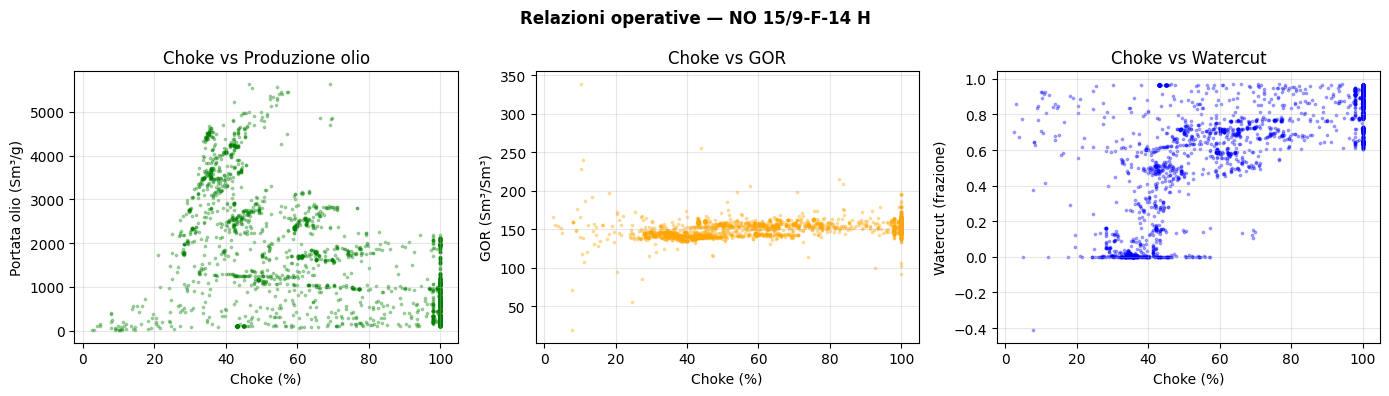

In [2]:
# ── RELAZIONE CHOKE vs PRODUZIONE ────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Choke vs Olio
axes[0].scatter(df_prod['AVG_CHOKE_SIZE_P'], df_prod['BORE_OIL_VOL'],
                s=3, alpha=0.3, color='green')
axes[0].set_xlabel('Choke (%)')
axes[0].set_ylabel('Portata olio (Sm³/g)')
axes[0].set_title('Choke vs Produzione olio')
axes[0].grid(True, alpha=0.3)

# Choke vs GOR
axes[1].scatter(df_prod['AVG_CHOKE_SIZE_P'], df_prod['GOR'],
                s=3, alpha=0.3, color='orange')
axes[1].set_xlabel('Choke (%)')
axes[1].set_ylabel('GOR (Sm³/Sm³)')
axes[1].set_title('Choke vs GOR')
axes[1].grid(True, alpha=0.3)

# Choke vs Watercut
axes[2].scatter(df_prod['AVG_CHOKE_SIZE_P'], df_prod['WATERCUT'],
                s=3, alpha=0.3, color='blue')
axes[2].set_xlabel('Choke (%)')
axes[2].set_ylabel('Watercut (frazione)')
axes[2].set_title('Choke vs Watercut')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Relazioni operative — {pozzo}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [3]:
# ── SIMULATORE DI PRODUZIONE ─────────────────────────────────────────────────
# Il simulatore stima la produzione giornaliera dato:
# - il giorno nella vita del pozzo (t)
# - l'apertura del choke (choke_pct)
# - lo stato attuale del reservoir (pressione cumulativa)

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# Usiamo i dati reali per calibrare il simulatore
features_sim = ['DAYS', 'AVG_CHOKE_SIZE_P', 'WATERCUT', 'GOR',
                'AVG_DOWNHOLE_PRESSURE', 'ON_STREAM_HRS']

df_sim = df_prod[features_sim + ['BORE_OIL_VOL']].dropna().copy()

X_sim = df_sim[features_sim].values
y_sim = df_sim['BORE_OIL_VOL'].values

# Split train/test
X_tr, X_te, y_tr, y_te = train_test_split(
    X_sim, y_sim, test_size=0.2, shuffle=False, random_state=42
)

# Gradient Boosting come simulatore
simulatore = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
simulatore.fit(X_tr, y_tr)

# Validiamo il simulatore
from sklearn.metrics import mean_absolute_percentage_error
y_pred_sim = simulatore.predict(X_te)
mape_sim = mean_absolute_percentage_error(y_te, y_pred_sim) * 100
r2_sim = 1 - np.sum((y_te - y_pred_sim)**2) / np.sum((y_te - y_te.mean())**2)

print(f"Simulatore calibrato — MAPE: {mape_sim:.1f}%  R²: {r2_sim:.3f}")
print("Il simulatore è pronto per l'ottimizzazione!")

Simulatore calibrato — MAPE: 63.1%  R²: -2.094
Il simulatore è pronto per l'ottimizzazione!


In [4]:
# ── SIMULATORE MIGLIORATO ─────────────────────────────────────────────────────

# Aggiungiamo produzione cumulativa e rolling average
df_prod['OIL_CUMSUM']  = df_prod['BORE_OIL_VOL'].cumsum()
df_prod['OIL_ROLL30']  = df_prod['BORE_OIL_VOL'].rolling(30).mean()
df_prod['OIL_LAG1']    = df_prod['BORE_OIL_VOL'].shift(1)

features_sim2 = ['DAYS', 'AVG_CHOKE_SIZE_P', 'WATERCUT', 'GOR',
                 'AVG_DOWNHOLE_PRESSURE', 'ON_STREAM_HRS',
                 'OIL_CUMSUM', 'OIL_ROLL30', 'OIL_LAG1']

df_sim2 = df_prod[features_sim2 + ['BORE_OIL_VOL']].dropna().copy()

X_sim2 = df_sim2[features_sim2].values
y_sim2 = df_sim2['BORE_OIL_VOL'].values

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_sim2, y_sim2, test_size=0.2, shuffle=False, random_state=42
)

simulatore2 = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
simulatore2.fit(X_tr2, y_tr2)

y_pred_sim2 = simulatore2.predict(X_te2)
mape_sim2 = mean_absolute_percentage_error(y_te2, y_pred_sim2) * 100
r2_sim2 = 1 - np.sum((y_te2 - y_pred_sim2)**2) / np.sum((y_te2 - y_te2.mean())**2)

print(f"Simulatore v1 — MAPE: {mape_sim:.1f}%  R²: {r2_sim:.3f}")
print(f"Simulatore v2 — MAPE: {mape_sim2:.1f}%  R²: {r2_sim2:.3f}")

Simulatore v1 — MAPE: 63.1%  R²: -2.094
Simulatore v2 — MAPE: 54.4%  R²: -1.424


In [5]:
# ── SIMULATORE V3 — APPROCCIO RELATIVO ───────────────────────────────────────
# Invece di predire la produzione assoluta, predichiamo la VARIAZIONE
# rispetto alla media mobile degli ultimi 30 giorni
# Questo è molto più stabile e utile per l'ottimizzazione

df_prod['OIL_RATIO'] = df_prod['BORE_OIL_VOL'] / df_prod['OIL_ROLL30']

features_sim3 = ['AVG_CHOKE_SIZE_P', 'WATERCUT', 'GOR',
                 'AVG_DOWNHOLE_PRESSURE', 'ON_STREAM_HRS']

df_sim3 = df_prod[features_sim3 + ['OIL_RATIO']].dropna().copy()

# Rimuoviamo outlier (ratio > 3 o < 0.1 sono shut-in o errori)
df_sim3 = df_sim3[(df_sim3['OIL_RATIO'] > 0.1) & (df_sim3['OIL_RATIO'] < 3.0)]

X_sim3 = df_sim3[features_sim3].values
y_sim3 = df_sim3['OIL_RATIO'].values

X_tr3, X_te3, y_tr3, y_te3 = train_test_split(
    X_sim3, y_sim3, test_size=0.2, shuffle=False, random_state=42
)

simulatore3 = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
simulatore3.fit(X_tr3, y_tr3)

y_pred_sim3 = simulatore3.predict(X_te3)
mape_sim3 = mean_absolute_percentage_error(y_te3, y_pred_sim3) * 100
r2_sim3 = 1 - np.sum((y_te3 - y_pred_sim3)**2) / np.sum((y_te3 - y_te3.mean())**2)

print(f"Simulatore v1 — MAPE: {mape_sim:.1f}%   R²: {r2_sim:.3f}  (produzione assoluta)")
print(f"Simulatore v2 — MAPE: {mape_sim2:.1f}%   R²: {r2_sim2:.3f}  (+ cumsum e lag)")
print(f"Simulatore v3 — MAPE: {mape_sim3:.1f}%   R²: {r2_sim3:.3f}  (variazione relativa)")

Simulatore v1 — MAPE: 63.1%   R²: -2.094  (produzione assoluta)
Simulatore v2 — MAPE: 54.4%   R²: -1.424  (+ cumsum e lag)
Simulatore v3 — MAPE: 17.0%   R²: -2.227  (variazione relativa)


In [6]:
# ── OTTIMIZZAZIONE BAYESIANA CON OPTUNA ──────────────────────────────────────

# Prezzo del petrolio (Brent medio campo Volve ~2010-2016)
PREZZO_OLIO = 80  # USD/bbl
BBL_PER_SM3 = 6.29  # conversione Sm³ → barili

# Stato attuale del pozzo (usiamo gli ultimi 30 giorni come baseline)
ultimi_30 = df_prod.tail(30)
baseline_olio     = ultimi_30['BORE_OIL_VOL'].mean()
baseline_watercut = ultimi_30['WATERCUT'].mean()
baseline_gor      = ultimi_30['GOR'].mean()
baseline_pressure = ultimi_30['AVG_DOWNHOLE_PRESSURE'].mean()
baseline_choke    = ultimi_30['AVG_CHOKE_SIZE_P'].mean()

print(f"Stato baseline (ultimi 30 giorni):")
print(f"  Portata olio media:  {baseline_olio:.1f} Sm³/g")
print(f"  Watercut medio:      {baseline_watercut:.3f}")
print(f"  GOR medio:           {baseline_gor:.1f} Sm³/Sm³")
print(f"  Pressione media:     {baseline_pressure:.1f} bar")
print(f"  Choke medio:         {baseline_choke:.1f}%")

def simula_produzione(choke_pct, giorni=30):
    """
    Dato un valore di choke, simula la produzione media
    per i prossimi 'giorni' giorni usando il simulatore v3
    """
    features = np.array([[
        choke_pct,
        baseline_watercut,
        baseline_gor,
        baseline_pressure,
        24.0  # ore in produzione al giorno
    ]])
    ratio = simulatore3.predict(features)[0]
    ratio = np.clip(ratio, 0.1, 2.5)  # limiti fisici
    return baseline_olio * ratio

def objective(trial):
    """
    Funzione obiettivo per Optuna:
    massimizza il ricavo netto penalizzando watercut alto
    """
    # Variabile da ottimizzare: apertura del choke
    choke = trial.suggest_float('choke_pct', 20.0, 100.0)

    # Produzione simulata
    q_olio = simula_produzione(choke)

    # Ricavo giornaliero in USD
    ricavo = q_olio * BBL_PER_SM3 * PREZZO_OLIO

    # Penalità per watercut alto (>0.90 = quasi tutto acqua)
    penalita_wc = 0
    if baseline_watercut > 0.90:
        penalita_wc = ricavo * 0.3  # riduciamo il ricavo del 30%

    # Penalità per choke troppo alto (rischio coning)
    penalita_choke = 0
    if choke > 85:
        penalita_choke = ricavo * 0.1

    return ricavo - penalita_wc - penalita_choke

# Ottimizzazione
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"\n══ RISULTATI OTTIMIZZAZIONE ══")
print(f"Choke ottimale:          {study.best_params['choke_pct']:.1f}%")
print(f"Choke baseline:          {baseline_choke:.1f}%")
print(f"Produzione baseline:     {baseline_olio:.1f} Sm³/g")
print(f"Produzione ottimizzata:  {simula_produzione(study.best_params['choke_pct']):.1f} Sm³/g")

Stato baseline (ultimi 30 giorni):
  Portata olio media:  102.7 Sm³/g
  Watercut medio:      0.966
  GOR medio:           161.0 Sm³/Sm³
  Pressione media:     269.0 bar
  Choke medio:         55.5%


  0%|          | 0/200 [00:00<?, ?it/s]


══ RISULTATI OTTIMIZZAZIONE ══
Choke ottimale:          71.3%
Choke baseline:          55.5%
Produzione baseline:     102.7 Sm³/g
Produzione ottimizzata:  81.3 Sm³/g


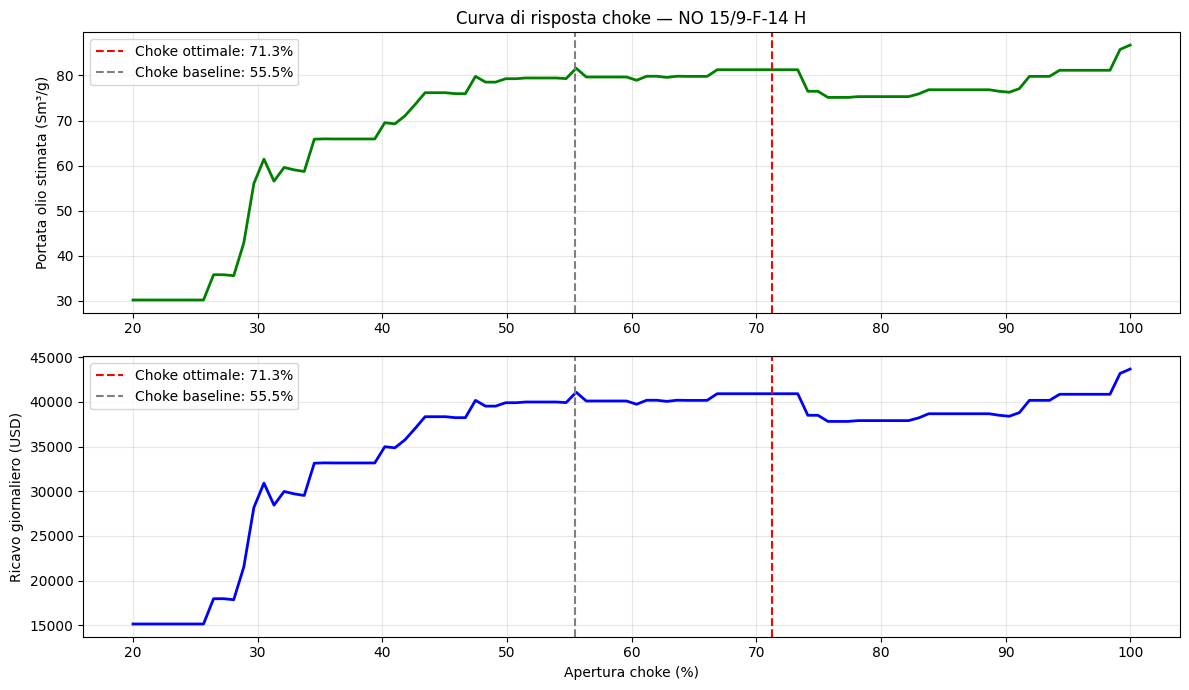

══ CONFRONTO SCENARI ══
Scenario                Choke   Olio Sm³/g   Ricavo USD/g
----------------------------------------------------------
Conservativo             40.0         69.5          34978
Baseline                 55.5         81.6          41064
Ottimale AI              71.3         81.3          40900
Aggressivo               95.0         81.2          40839


In [7]:
# ── CURVA DI RISPOSTA CHOKE ───────────────────────────────────────────────────

choke_values = np.linspace(20, 100, 100)
produzioni   = [simula_produzione(c) for c in choke_values]
ricavi       = [q * BBL_PER_SM3 * PREZZO_OLIO for q in produzioni]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

# Produzione vs choke
ax1.plot(choke_values, produzioni, color='green', linewidth=2)
ax1.axvline(study.best_params['choke_pct'], color='red', 
            linestyle='--', linewidth=1.5, label=f"Choke ottimale: {study.best_params['choke_pct']:.1f}%")
ax1.axvline(baseline_choke, color='gray', 
            linestyle='--', linewidth=1.5, label=f"Choke baseline: {baseline_choke:.1f}%")
ax1.set_ylabel('Portata olio stimata (Sm³/g)')
ax1.set_title(f'Curva di risposta choke — {pozzo}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Ricavo vs choke
ax2.plot(choke_values, ricavi, color='blue', linewidth=2)
ax2.axvline(study.best_params['choke_pct'], color='red',
            linestyle='--', linewidth=1.5, label=f"Choke ottimale: {study.best_params['choke_pct']:.1f}%")
ax2.axvline(baseline_choke, color='gray',
            linestyle='--', linewidth=1.5, label=f"Choke baseline: {baseline_choke:.1f}%")
ax2.set_xlabel('Apertura choke (%)')
ax2.set_ylabel('Ricavo giornaliero (USD)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confronto scenari
print("══ CONFRONTO SCENARI ══")
print(f"{'Scenario':<20} {'Choke':>8} {'Olio Sm³/g':>12} {'Ricavo USD/g':>14}")
print("-" * 58)
for nome, choke in [('Conservativo', 40), ('Baseline', baseline_choke), 
                     ('Ottimale AI', study.best_params['choke_pct']), ('Aggressivo', 95)]:
    q = simula_produzione(choke)
    r = q * BBL_PER_SM3 * PREZZO_OLIO
    print(f"{nome:<20} {choke:>8.1f} {q:>12.1f} {r:>14.0f}")